# 클러스터링 EDA — 공고 제목 임베딩

대상: OpenSearch `bid_chunks` 제목 벡터 25,035건 (BGE-M3, 1024차원)

## 0. 환경 확인

In [3]:
# 분석에 쓰는 라이브러리가 가상환경(.venv)에 제대로 설치됐는지 확인한다
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn
import umap

print("numpy", np.__version__)
print("pandas", pd.__version__)
print("matplotlib", matplotlib.__version__)
print("scikit-learn", sklearn.__version__)

# 그래프에서 한글이 깨지지 않도록 윈도우 기본 한글 폰트를 지정한다
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False  # 마이너스 부호 깨짐 방지

numpy 2.4.6
pandas 3.0.5
matplotlib 3.11.1
scikit-learn 1.9.0


## 1. 데이터 로드

In [4]:
import json
from pathlib import Path

CACHE = Path("cache")

# 제목 임베딩 벡터 (25035, 1024) - fetch 단계에서 OpenSearch로부터 받아 저장한 것
X = np.load(CACHE / "vectors.npy")

# 벡터와 같은 순서로 정렬된 메타데이터 (bid_id, 제목, 업종)
# X[i] 와 df.iloc[i] 는 같은 공고를 가리킨다 - 한쪽만 정렬/필터링하면 짝이 어긋난다
meta = json.loads((CACHE / "meta.json").read_text(encoding="utf-8"))
df = pd.DataFrame(meta)

print("벡터:", X.shape, X.dtype)
print("메타:", df.shape)
assert len(X) == len(df), "벡터와 메타 개수가 다르면 캐시가 어긋난 것"
df.head()

벡터: (25035, 1024) float32
메타: (25035, 3)


,bid_id,title,biz_div
0,20160237767_009,조명제어장치외 1종,thng
1,20160322124_012,흙콘크리트,thng
2,20160342075_005,수목보호용지지대,thng
3,20160342485_006,인쇄기,NaN
4,20160343058_007,목제창,thng


## 2. 제목 텍스트 점검

### 2-1. 업종별 건수

In [5]:
# 업종(biz_div) 분포 - 업종별로 나눠 클러스터링할 예정이라 규모 감각이 필요하다
# NaN(미매칭)은 RDS bid_table에 없는 bid_id - 원인은 2-4에서 확인한다
counts = df["biz_div"].value_counts(dropna=False)
print(counts)
print(f"\n미매칭: {df['biz_div'].isna().sum()}건 ({df['biz_div'].isna().mean()*100:.2f}%)")

biz_div
servc     12323
thng       9399
cnstwk     1819
NaN         929
frgcpt      565
Name: count, dtype: int64

미매칭: 929건 (3.71%)


### 2-2. 제목 길이 분포

count    25035.000000
mean        27.860116
std          9.472017
min          2.000000
25%         22.000000
50%         27.000000
75%         33.000000
max        145.000000
Name: title_len, dtype: float64

5자 이하: 116건 (0.46%)
['경관조명', '경보장치', '계단부품', '고무마루재', '교량받침', '군복', '금속문세트', '금속제창', '기동복', '김치냉장고', '납골안치단', '내벽패널', '냉난방기', '냉방기', '도로표지병', '동결건조기', '동보장치', '디젤발전기', '레미콘', '롤링문']


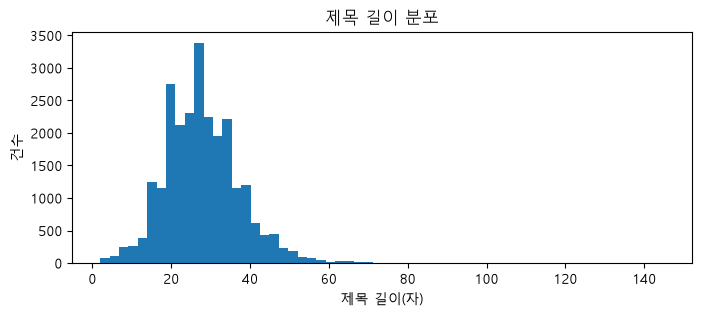

In [6]:
# 제목 길이 분포 - 너무 짧은 제목은 벡터가 의미를 담기 어려울 수 있어 확인한다
df["title_len"] = df["title"].str.len()
print(df["title_len"].describe())

# 5자 이하 제목 표본 확인
# "레미콘", "교량받침" 같은 정상 물품명이면 노이즈가 아니므로 제외하지 않는다
short = df[df["title_len"] <= 5]
print(f"\n5자 이하: {len(short)}건 ({len(short)/len(df)*100:.2f}%)")
print(sorted(short["title"].unique())[:20])

plt.figure(figsize=(8, 3))
plt.hist(df["title_len"], bins=60)
plt.xlabel("제목 길이(자)")
plt.ylabel("건수")
plt.title("제목 길이 분포")
plt.show()

### 2-3. 제목 중복 구조

In [7]:
# 제목 중복 구조 확인
# 같은 제목은 임베딩 벡터도 동일해서 한 좌표에 여러 점이 겹친다
# K-means는 평균으로 중심을 옮기므로, 중복이 많으면 중심이 그쪽으로 끌려가 클러스터가 왜곡된다
dup_counts = df["title"].value_counts()
dup_titles = dup_counts[dup_counts > 1]

print(f"전체 행: {len(df)}")
print(f"고유 제목: {df['title'].nunique()}")
print(f"중복되는 제목 종류: {len(dup_titles)}")
print(f"중복으로 인한 잉여 행 수: {dup_counts.sum() - dup_counts.count()}")
print(f"최대 반복 횟수: {dup_titles.max()}건")

print("\n가장 많이 반복된 제목 상위 10개")
print(dup_titles.head(10))

# 중복 원인 확인 - bid_id 는 "공고번호_차수" 구조라 차수 변경(재공고)이면 정상적인 중복이다
sample_title = dup_titles.index[0]
print(f"\n예시 - '{sample_title}'")
print(df[df["title"] == sample_title]["bid_id"].tolist())

전체 행: 25035
고유 제목: 17121
중복되는 제목 종류: 4655
중복으로 인한 잉여 행 수: 7914
최대 반복 횟수: 8건

가장 많이 반복된 제목 상위 10개
title
2025년 부잔교 설치 및 보수공사(내저항) 관급자재[잔교] 구입    8
고융점 금속 전자빔 증착기                          7
함안군 지하시설물 전산화 사업 (1차분)                  7
(가칭)삼봉중 신축 공사                           7
2026년 생명자원정보서비스 통합 유지관리                 6
2026년 남해군 재해위험지구 조기경보시스템 유지보수 용역        6
2026년 영업자 식품안전관리 지원사업                   6
수원시 장애인 버스요금 지원 시스템 구축 용역               6
서울송파우체국 아파트전담 소포우편물 위탁배달용역              6
2026년 항공안전 IT 시스템 운영 및 유지관리             6
Name: count, dtype: int64

예시 - '2025년 부잔교 설치 및 보수공사(내저항) 관급자재[잔교] 구입'
['R26BK01348679_000', 'R26BK01418034_000', 'R26BK01443848_000', 'R26BK01467983_000', 'R26BK01467983_001', 'R26BK01516294_000', 'R26BK01537865_000', 'R26BK01550691_000']


### 2-4. 업종 미매칭 규명

In [8]:
# 업종 미매칭(biz_div가 NaN) 건의 정체를 확인한다
# OpenSearch에는 제목 벡터가 있는데 RDS bid_table에는 해당 bid_id가 없는 경우다
unmatched = df[df["biz_div"].isna()].copy()
print(f"미매칭: {len(unmatched)}건")

# bid_id 형식으로 시기를 구분한다 - 구형(숫자로 시작)과 신형(R로 시작, 나라장터 개편 이후)
unmatched["id_form"] = unmatched["bid_id"].str.startswith("R").map(
    {True: "신형(R##BK...)", False: "구형(숫자)"}
)
print(unmatched["id_form"].value_counts())
print("\n표본:")
print(unmatched[["bid_id", "title"]].head(10))

미매칭: 929건
id_form
신형(R##BK...)    920
구형(숫자)            9
Name: count, dtype: int64

표본:
                bid_id                              title
3      20160342485_006                                인쇄기
6      20160346487_004                               팩스기기
21     20160635388_010                                분전반
40     20160823909_008                             토너외 1종
50     20161017306_006                              접속단자대
63     20161231117_007                               수중펌프
85     20170536235_012                            배전반외 2종
118    20180115247_005                               리셉터클
154    20210343316_003                            체험활동서비스
210  R25BK01146472_001  ASF 등 야생동물질병 먹이(미끼) 백신 개발 및 제재 평가


In [9]:
# 미매칭이 차수 불일치인지, 공고 자체가 RDS에 없는 것인지 확인한다
# bid_id 뒤의 차수(_000, _001)를 떼고 공고번호만으로 RDS에 존재하는지 재조회한다
# 차수만 다르면 "차수 불일치"고, 공고번호로도 안 잡히면 "공고 자체가 RDS에 없음"이다
import re
import psycopg2

def load_env(path="../.env"):
    # 노트북 기본 작업 디렉토리는 clustering/ 이고 .env는 리포 루트(bidding-agent/)에 있다
    env = {}
    for line in Path(path).read_text(encoding="utf-8").splitlines():
        m = re.match(r"^([A-Za-z_]+)=(.*)$", line.strip())
        if m:
            env[m.group(1)] = m.group(2).strip().strip('"').strip("'")
    return env

env = load_env()
ntce_nos = list({b.rsplit("_", 1)[0] for b in unmatched["bid_id"]})

with psycopg2.connect(
    host=env["RDS_Host"], dbname=env["RDS_DB"],
    user=env["RDS_Username"], password=env["RDS_Password"], port=5432,
) as conn, conn.cursor() as cur:
    cur.execute(
        "SELECT count(DISTINCT bid_ntce_no) FROM bid_table WHERE bid_ntce_no = ANY(%s)",
        (ntce_nos,),
    )
    found = cur.fetchone()[0]

print(f"미매칭 bid_id 기준 공고번호 종류: {len(ntce_nos)}")
print(f"그중 RDS에 존재: {found}건 ({found/len(ntce_nos)*100:.1f}%)")
print(
    "결론: 차수 불일치 - 공고 자체는 RDS에 있음" if found / len(ntce_nos) >= 0.5
    else "결론: 공고 자체가 RDS에 없음 (삭제됐거나 적재 시점 차이)"
)

미매칭 bid_id 기준 공고번호 종류: 912
그중 RDS에 존재: 38건 (4.2%)
결론: 공고 자체가 RDS에 없음 (삭제됐거나 적재 시점 차이)


## 3. 임베딩 공간 점검 (원본, 중복 포함 상태 기준)

### 3-1. 벡터 norm 분포

In [10]:
# 벡터 길이(L2 norm) 분포 확인
# 이미 1로 정규화되어 있다면 별도 정규화 없이 코사인 유사도 기준 거리 계산이 가능하다
norms = np.linalg.norm(X, axis=1)
print(f"min={norms.min():.4f} max={norms.max():.4f} mean={norms.mean():.4f} std={norms.std():.4f}")

already_normalized = abs(norms.mean() - 1) < 0.01 and norms.std() < 0.01
print("이미 정규화됨" if already_normalized else "정규화 필요 - normalize() 적용해야 함")

min=0.9997 max=1.0003 mean=1.0000 std=0.0002
이미 정규화됨


### 3-2. 무작위 쌍 코사인 유사도 분포

쌍 개수: 199,992
평균 0.4125 / 표준편차 0.0761
  p1: 0.2659
  p5: 0.3037
  p25: 0.3598
  p50: 0.4039
  p75: 0.4555
  p95: 0.5525
  p99: 0.6283


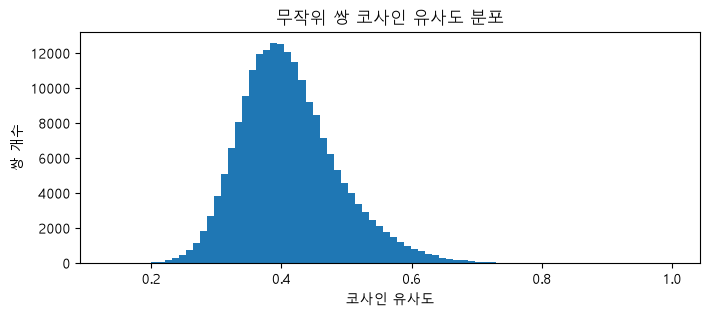

In [11]:
# 무작위 쌍의 코사인 유사도 분포 - 이번 EDA에서 가장 중요한 지표
# 서로 무관한 두 공고는 유사도가 낮게(0 근처) 나오는 게 정상이다
# 분포가 전체적으로 높은 값(예: 0.8 이상)에 몰려 있다면 벡터끼리 변별력이 없다는 뜻이고
# 그 경우 어떤 클러스터링 알고리즘을 써도 그룹이 잘 안 나뉜다
from sklearn.preprocessing import normalize

rng = np.random.default_rng(42)
Xn = normalize(X)  # 정규화 후에는 내적 = 코사인 유사도

n_pairs = 200_000
i = rng.integers(0, len(Xn), n_pairs)
j = rng.integers(0, len(Xn), n_pairs)
mask = i != j  # 자기 자신과의 쌍은 제외
sims = np.einsum("ij,ij->i", Xn[i[mask]], Xn[j[mask]])

print(f"쌍 개수: {mask.sum():,}")
print(f"평균 {sims.mean():.4f} / 표준편차 {sims.std():.4f}")
for p in (1, 5, 25, 50, 75, 95, 99):
    print(f"  p{p}: {np.percentile(sims, p):.4f}")

plt.figure(figsize=(8, 3))
plt.hist(sims, bins=80)
plt.xlabel("코사인 유사도")
plt.ylabel("쌍 개수")
plt.title("무작위 쌍 코사인 유사도 분포")
plt.show()

### 3-3. 최근접 이웃 거리 분포

표본 3000건, k=10
1등 이웃 거리 - 평균 0.0962 / 중앙값 0.0000
10등 이웃 거리 - 평균 0.2981


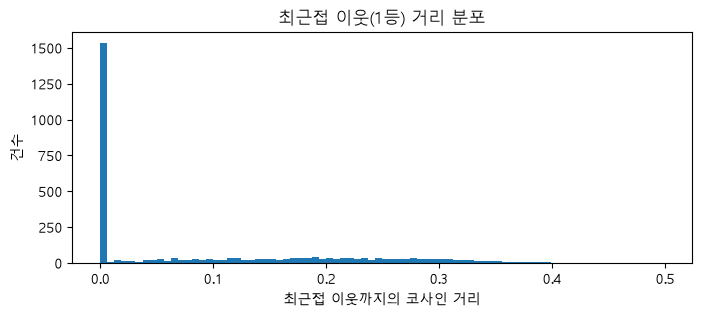

In [12]:
# 최근접 이웃까지의 거리 분포 - 데이터가 얼마나 밀집해 있는지 본다
# 이 값은 4단계에서 HDBSCAN을 쓸 경우 min_cluster_size, min_samples 초기값을 정하는 근거가 된다
# 전체 쌍(25035 x 25035)은 계산량이 커서 일부만 표본으로 뽑아 계산한다
sample_size = 3000
k = 10

idx = rng.choice(len(Xn), sample_size, replace=False)
sim_to_all = Xn[idx] @ Xn.T  # (sample_size, 전체) 코사인 유사도
sim_to_all[np.arange(len(idx)), idx] = -np.inf  # 자기 자신 제외

topk_sim = np.sort(sim_to_all, axis=1)[:, -k:][:, ::-1]
topk_dist = 1 - topk_sim  # 코사인 거리 = 1 - 코사인 유사도

print(f"표본 {sample_size}건, k={k}")
print(f"1등 이웃 거리 - 평균 {topk_dist[:, 0].mean():.4f} / 중앙값 {np.median(topk_dist[:, 0]):.4f}")
print(f"{k}등 이웃 거리 - 평균 {topk_dist[:, -1].mean():.4f}")

plt.figure(figsize=(8, 3))
plt.hist(topk_dist[:, 0], bins=80)
plt.xlabel("최근접 이웃까지의 코사인 거리")
plt.ylabel("건수")
plt.title("최근접 이웃(1등) 거리 분포")
plt.show()

**해석**

- 1등 이웃 거리 **중앙값이 0.0000** — 표본 3,000건 중 절반 이상이 자신과 완전히 동일한(코사인 거리 0) 벡터를 가장 가까운 이웃으로 갖는다. 즉 표본의 과반이 제목 중복이다.
- 평균(0.0962)이 중앙값(0.0000)보다 훨씬 큼 — 분포가 한쪽으로 쏠려 있다는 뜻. "완전 중복이라 거리 0인 점들"과 "고유해서 어느 정도 거리가 있는 점들"이 섞여 있어서다.
- 10등 이웃 거리(0.2981)는 1등(0.0962)의 3배 이상 — 중복을 한두 개 벗어나면 실제 밀도는 그렇게 조밀하지 않다는 뜻이다.

**2-3과의 연결**: title 문자열 비교로 찾은 중복(7,914건, 31.6%)이 벡터 거리 관점에서도 그대로 확인됐다. 접근 방식이 다른 두 측정(문자열 일치 vs 벡터 거리)이 같은 결론을 가리키므로, **중복 제거는 선택이 아니라 필수 전처리**로 확정한다.

**실무적 함의**: 이 상태로 HDBSCAN의 `min_cluster_size`/`min_samples`를 바로 튜닝하면 안 된다 — 거리 분포 자체가 중복 때문에 왜곡돼 있어서, 파라미터가 "진짜 밀도"가 아니라 "중복 밀도"에 맞춰진다. 전처리(중복 제거) 이후에 이 지표를 다시 재는 게 순서상 맞다.

### 3-4. PCA 누적 설명 분산

  2차원 ->  10.0%
  5차원 ->  16.9%
 10차원 ->  23.9%
 20차원 ->  32.7%
 50차원 ->  48.7%
100차원 ->  64.7%
200차원 ->  82.2%


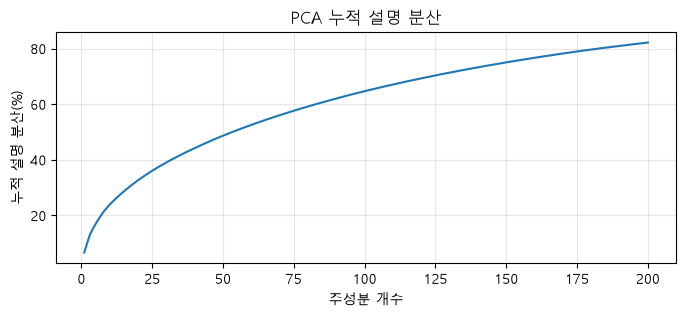

In [13]:
# PCA 누적 설명 분산 - 선형 축소로 몇 차원까지 줄여야 정보를 얼마나 보존하는지 확인한다
# 주의: "설명 분산"은 "의미 보존율"이 아니다. 버려지는 분산에는 노이즈도 섞여 있다
# 다만 2차원이 몇 %인지 보면, 2D 시각화만으로 클러스터를 판단해도 되는지 감을 잡을 수 있다
# svd_solver="randomized"를 명시함 - "auto"가 상황에 따라 훨씬 느린 "full"(완전 SVD)을
# 고르는 경우가 있어서, 200개 성분만 필요한 이번 목적엔 근사 계산인 randomized로 충분하다
from sklearn.decomposition import PCA

pca = PCA(n_components=200, random_state=42, svd_solver="randomized").fit(Xn)
cum = np.cumsum(pca.explained_variance_ratio_)

for n in (2, 5, 10, 20, 50, 100, 200):
    print(f"{n:3}차원 -> {cum[n-1]*100:5.1f}%")

plt.figure(figsize=(8, 3))
plt.plot(range(1, 201), cum * 100)
plt.xlabel("주성분 개수")
plt.ylabel("누적 설명 분산(%)")
plt.title("PCA 누적 설명 분산")
plt.grid(alpha=0.3)
plt.show()

**해석**

- **2차원은 10.0%뿐** — 4단계 PCA 2D/UMAP 2D 시각화는 정보의 10분의 1만 보고 판단하는 것이다. 그림에서 뭉쳐 보인다고 클러스터가 없다고 단정하면 안 되는 이유가 여기서 수치로 확인된다.
- **200차원까지 늘려도 82.2%** — 나머지 17.8%는 여전히 못 담는다. 정보가 소수의 축에 몰려있지 않고 1024개 축 전반에 고르게 퍼져 있다는 뜻이고, 이건 텍스트 임베딩의 전형적인 특성이다.
- **50차원에서 48.7%로 절반 수준** — 다음 단계(차원축소)에서 UMAP을 10~50차원 정도로 줄여 클러스터링할 계획인데, PCA 기준으로는 이 구간이 정보의 절반 정도만 보존한다는 뜻이다. 다만 UMAP은 선형(PCA)과 달리 이웃 관계 보존을 목표로 하는 비선형 축소라 같은 차원에서 실질적으로 더 많은 구조를 살릴 수 있다 — 그래서 "PCA 50차원=48.7%"를 "UMAP 50차원도 48.7%만 보존"으로 곧바로 해석하면 안 된다.

**실무적 함의**: 선형 압축(PCA)만으로는 이 데이터를 효율적으로 줄이기 어렵다는 근거가 된다. 다음 단계에서 PCA 선행 여부를 실험할 때(3-B), "PCA 먼저 하면 정보 손실이 이미 이 지점부터 크다"는 걸 감안해야 한다.

## 4. 구조 확인 (시각화, 원본 기준)

### 4-1. PCA 2D

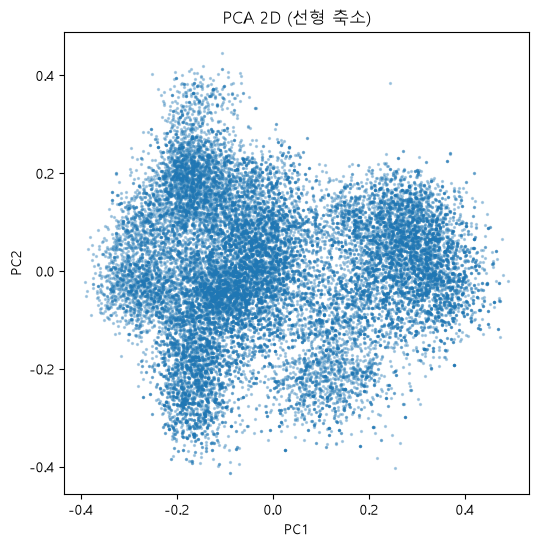

In [14]:
# PCA로 2차원까지 축소해 산점도로 본다
# 3-4에서 확인했듯 2D는 정보의 일부만 담으므로, 여기서 뭉쳐 보인다고 클러스터가 없다고
# 단정하면 안 된다. UMAP(4-2) 결과와 비교하기 위한 참고용이다
pca2 = PCA(n_components=2, random_state=42).fit_transform(Xn)

plt.figure(figsize=(6, 6))
plt.scatter(pca2[:, 0], pca2[:, 1], s=2, alpha=0.3)
plt.title("PCA 2D (선형 축소)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

**해석 (4-1 PCA 2D)**

두 개의 뭉치가 느슨하게 나뉘어 보이지만 경계가 뚜렷하지 않고 중앙에서 크게 겹친다. 3-4에서 확인했듯 2차원은 전체 정보의 10.0%만 담고 있어서, 이 정도로 뭉개져 보이는 건 예상된 결과다. **이 그림만 보고 "클러스터가 없다"고 판단하면 안 된다** — 판단은 4-2(UMAP)와 비교해서 내린다.

### 4-2. UMAP 2D

c:\Users\user\Desktop\PROJECTS\bidding-agent\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\user\Desktop\PROJECTS\bidding-agent\.venv\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


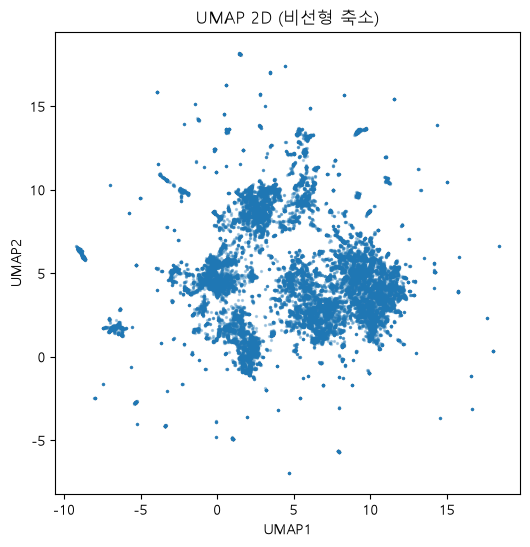

In [15]:
# UMAP으로 2차원까지 축소해 산점도로 본다
# UMAP은 비선형이라 이웃 관계(가까운 것끼리 가깝게)를 PCA보다 잘 보존하는 편이다
# 여기 쓰는 파라미터는 시각화 확인용 기본값이고, 실제 클러스터링(4단계)에서는
# n_components를 10~50 정도로 늘려 별도로 튜닝해야 한다
import umap

reducer = umap.UMAP(n_components=2, metric="cosine", random_state=42)
umap2 = reducer.fit_transform(Xn)

plt.figure(figsize=(6, 6))
plt.scatter(umap2[:, 0], umap2[:, 1], s=2, alpha=0.3)
plt.title("UMAP 2D (비선형 축소)")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.show()

**해석 (4-2 UMAP 2D)**

PCA(4-1)와 완전히 다른 그림이 나온다 — 중앙에 큰 덩어리 하나(사실상 두 개가 붙어 있는 모양)와, 그 주변에 **본체와 뚜렷이 떨어진 작은 섬 같은 군집들**이 여러 개 보인다(왼쪽 끝의 길쭉한 군집, 좌상단의 작은 군집 등). PCA에서는 안 보이던 구조가 비선형 축소(UMAP)에서 드러난 것 — **클러스터링이 실제로 의미 있는 접근이라는 시각적 근거**다.

작은 섬들이 유독 촘촘하게 뭉쳐 있는 건, 2-3/5단계에서 확인한 **제목 중복(반복 발주 품목)이 벡터 공간에서 그대로 하나의 밀집점으로 뭉친 것**일 가능성이 크다 — 나중에 클러스터링 결과를 볼 때 이 작은 섬들이 실제로 그런지 확인해볼 필요가 있다.

### 4-3. 업종별 색칠

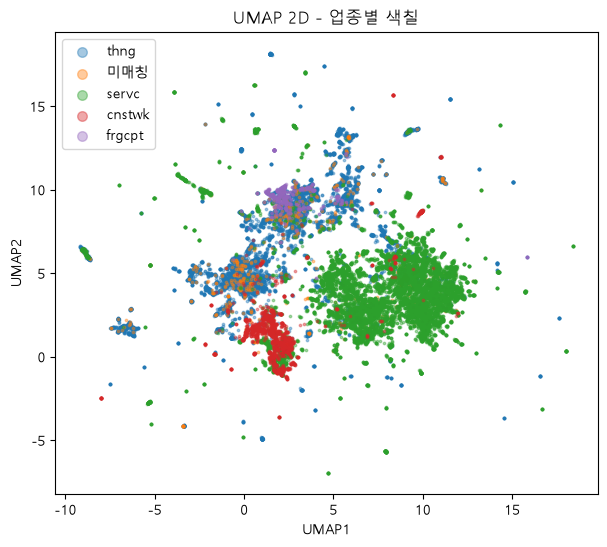

In [16]:
# 업종별로 색을 다르게 칠해서 업종끼리 실제로 구분되는지 확인한다
# 업종별로 뚜렷하게 갈라져 보이면, 업종을 나눠서 클러스터링하는 접근이 타당하다는 근거가 된다
# 반대로 다 섞여 보이면 업종 분리 없이 전체를 한 번에 다루는 편이 나을 수 있다
categories = df["biz_div"].fillna("미매칭")

plt.figure(figsize=(7, 6))
for cat in categories.unique():
    m = (categories == cat).to_numpy()
    plt.scatter(umap2[m, 0], umap2[m, 1], s=3, alpha=0.4, label=cat)
plt.legend(markerscale=4)
plt.title("UMAP 2D - 업종별 색칠")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.show()

**해석 (4-3 업종별 색칠)**

- **업종별로 각자의 영역이 뚜렷하다** — servc(초록)는 우측 큰 덩어리를 거의 독점하고, thng(파랑)는 상단 덩어리를 대부분 차지한다. cnstwk(빨강, 1,819건으로 건수는 적음)는 하단 중앙에 **자기만의 응집된 군집**을 형성한다. frgcpt(보라, 565건)도 상단 한쪽에 작지만 뚜렷한 섬을 이룬다. → **업종을 나눠서 클러스터링하는 접근이 타당하다**는 근거가 시각적으로 확인된다.
- **다만 완벽히 분리되진 않는다** — 중앙 덩어리 경계에서 초록·파랑이 상당히 섞인다. 업종별로 나눠도 그 안에 다른 업종 성격의 공고가 일부 섞여 들어올 수 있다는 뜻이다.
- **미매칭(주황)이 흩어져 있지 않고 thng(파랑) 영역에 몰려 있다** — 이건 2-4에서 확인한 내용과 정확히 들어맞는다. 미매칭 표본이 "인쇄기", "팩스기기", "분전반"처럼 전형적인 물품명이었는데, 벡터 공간에서도 실제로 물품(thng) 군집과 같은 자리에 위치한다. 즉 이 929건은 성격이 이상한 데이터가 아니라 **RDS에 없을 뿐 실제로는 물품 공고일 가능성이 높다.**
- **좌측의 작은 섬들은 특정 색 하나로 거의 채워져 있다** — 4-2에서 추정한 "중복 반복 발주가 뭉친 것"이라는 가설과 일치한다(하나의 업종 안에서 같은 품목이 반복 발주된 경우로 보인다).

## 5. 중복 제거

중복 처리는 학습(클러스터링) 단계에서만 필요하다. 배정(라벨링) 단계는 벡터가 같으면
자동으로 같은 결과가 나오므로("레미콘"이 나중에 또 들어와도 같은 벡터 → 같은 중심점),
운영 단계에서 별도의 중복 판단 로직이 필요 없다. 그래서 여기서 한 번만 정리한다.

### 5-1. 제거 실행

In [17]:
# 제목 기준으로 중복을 제거한다 - 첫 번째로 나온 행만 남긴다
# 2-3에서 확인했듯 중복은 차수 변경(재공고)과 반복 발주가 섞여 있는데,
# 둘 다 "제목 텍스트가 같다"는 조건으로 걸러지므로 구분 없이 title 기준 제거로 충분하다
dedup_mask = ~df["title"].duplicated(keep="first")

df_dedup = df[dedup_mask].reset_index(drop=True)
X_dedup = X[dedup_mask.to_numpy()]
Xn_dedup = normalize(X_dedup)

print(f"제거 전: {len(df):,}건")
print(f"제거 후: {len(df_dedup):,}건 (고유 제목만)")

# 벡터와 메타가 같은 순서로 짝지어져 있는지 다시 확인 (1단계와 같은 이유)
assert len(X_dedup) == len(df_dedup) == df["title"].nunique()

제거 전: 25,035건
제거 후: 17,121건 (고유 제목만)


### 5-2. 코사인 유사도 재확인 (제거 전/후 비교)

제거 전(3-2) -> 제거 후
  평균   0.4125  ->  0.4125
  중앙값 0.4039  ->  0.4046
  p99    0.6283  ->  0.6254


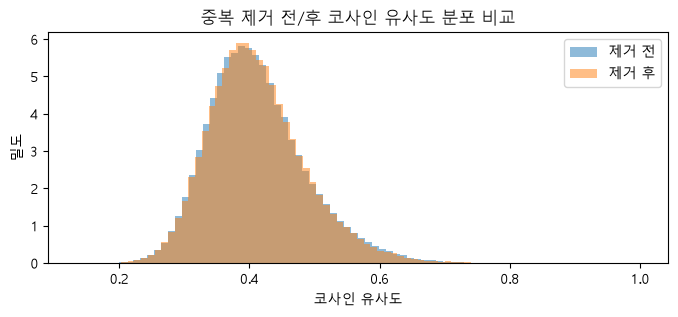

In [18]:
# 3-2와 같은 방법(무작위 쌍, 표본 20만 개)으로 제거 후 데이터의 코사인 유사도를 재본다
n_pairs = 200_000
i2 = rng.integers(0, len(Xn_dedup), n_pairs)
j2 = rng.integers(0, len(Xn_dedup), n_pairs)
mask2 = i2 != j2
sims_dedup = np.einsum("ij,ij->i", Xn_dedup[i2[mask2]], Xn_dedup[j2[mask2]])

print("제거 전(3-2) -> 제거 후")
print(f"  평균   {sims.mean():.4f}  ->  {sims_dedup.mean():.4f}")
print(f"  중앙값 {np.median(sims):.4f}  ->  {np.median(sims_dedup):.4f}")
print(f"  p99    {np.percentile(sims, 99):.4f}  ->  {np.percentile(sims_dedup, 99):.4f}")

plt.figure(figsize=(8, 3))
plt.hist(sims, bins=80, alpha=0.5, density=True, label="제거 전")
plt.hist(sims_dedup, bins=80, alpha=0.5, density=True, label="제거 후")
plt.xlabel("코사인 유사도")
plt.ylabel("밀도")
plt.title("중복 제거 전/후 코사인 유사도 분포 비교")
plt.legend()
plt.show()

**해석 (5-2 코사인 유사도, 전/후 비교)**

거의 변화가 없다(평균 0.4125 → 0.4125, 중앙값 0.4039 → 0.4046). 5-3의 극적인 변화와 대조적인데, 이유는 측정 방식의 차이에 있다.

- 5-2는 **완전히 무작위로 뽑은 두 문서**의 유사도다. 25,035건 중 무작위 두 개를 뽑으면 그중 하나가 다른 하나의 "정확한 중복"일 확률은 매우 낮다(중복은 4,655개 그룹에 몰려 있을 뿐 전체 쌍 조합에서 차지하는 비중은 작다). 그래서 전체 분포는 중복의 영향을 거의 안 받는다.
- 반면 5-3(최근접 이웃)은 정의상 **각 점마다 가장 가까운 상대를 찾는 것**이라, 중복이 존재하면 그 중복이 무조건 1등으로 뽑힌다. 중복의 영향이 "이웃 탐색"에는 집중되고 "무작위 비교"에는 희석되는 것이다.

**즉 중복은 전역 분포(5-2)를 왜곡하지 않고, 지역적 이웃 구조(5-3)만 왜곡한다.** 그래서 3-2(코사인 유사도)를 근거로 한 "클러스터링이 유효하다"는 판단은 중복 여부와 무관하게 그대로 유지되고, 영향을 받는 건 K 결정이나 밀도 기반 파라미터처럼 **국소 거리에 의존하는 지표들**뿐이다.

### 5-3. 최근접 이웃 거리 재확인 (제거 전/후 비교)

제거 전(3-3) -> 제거 후
  1등 이웃 거리 평균   0.0962  ->  0.2027
  1등 이웃 거리 중앙값 0.0000  ->  0.2032
  10등 이웃 거리 평균  0.2981  ->  0.3123


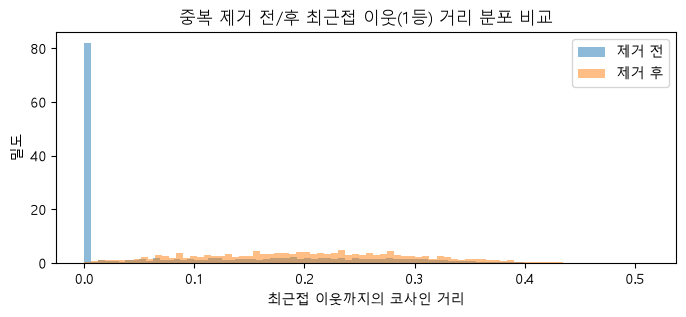

In [19]:
# 3-3과 같은 방법(표본 3000건, k=10)으로 제거 후 최근접 이웃 거리를 재본다
# 중복이 제대로 빠졌다면 1등 이웃 거리 중앙값이 더 이상 0.0000이 아니어야 한다
sample_size = 3000
k = 10

idx2 = rng.choice(len(Xn_dedup), min(sample_size, len(Xn_dedup)), replace=False)
sim_to_all2 = Xn_dedup[idx2] @ Xn_dedup.T
sim_to_all2[np.arange(len(idx2)), idx2] = -np.inf  # 자기 자신 제외
topk_sim2 = np.sort(sim_to_all2, axis=1)[:, -k:][:, ::-1]
topk_dist2 = 1 - topk_sim2

print("제거 전(3-3) -> 제거 후")
print(f"  1등 이웃 거리 평균   {topk_dist[:, 0].mean():.4f}  ->  {topk_dist2[:, 0].mean():.4f}")
print(f"  1등 이웃 거리 중앙값 {np.median(topk_dist[:, 0]):.4f}  ->  {np.median(topk_dist2[:, 0]):.4f}")
print(f"  10등 이웃 거리 평균  {topk_dist[:, -1].mean():.4f}  ->  {topk_dist2[:, -1].mean():.4f}")

plt.figure(figsize=(8, 3))
plt.hist(topk_dist[:, 0], bins=80, alpha=0.5, density=True, label="제거 전")
plt.hist(topk_dist2[:, 0], bins=80, alpha=0.5, density=True, label="제거 후")
plt.xlabel("최근접 이웃까지의 코사인 거리")
plt.ylabel("밀도")
plt.title("중복 제거 전/후 최근접 이웃(1등) 거리 분포 비교")
plt.legend()
plt.show()

**해석 (5-3 최근접 이웃 거리, 전/후 비교)**

- **1등 이웃 거리 중앙값이 0.0000 → 0.2032로 바뀌었다** — 3-3에서 예상한 그대로다. 표본 절반 이상을 차지하던 "거리 0(완전 동일 벡터)"이 사라지고, 이제는 실제 의미상 가장 가까운 **다른** 제목까지의 거리를 재고 있다. 그래프에서도 0 지점의 거대한 막대가 사라지고 0.05~0.4 구간에 고르게 퍼진 분포로 바뀐 게 그대로 보인다.
- **평균도 0.0962 → 0.2027로 약 2.1배 증가** — 중앙값과 같은 방향, 같은 원인이다.
- **10등 이웃 거리는 0.2981 → 0.3123로 거의 안 바뀜(+4.8%)** — 이게 중요한 확인이다. 중복의 영향은 "아주 가까운 이웃(1등)"에만 집중돼 있고, 10등 정도로 멀어지면 원래도 중복의 영향이 크지 않았다는 뜻이다. 최대 반복 횟수가 8건(2-3)이었던 것과도 맞아떨어진다 — 웬만한 제목은 중복이 있어도 7~8개를 넘지 않아 10등 밖의 이웃 구조까지는 왜곡시키지 못한 것.
- **제거 후 중앙값(0.20)이 여전히 작은 편** — 완전히 똑같은 벡터는 없어졌지만, "2026년 정보시스템 유지관리용역"과 "2026년 통합정보시스템 유지관리 용역사업"처럼 **표현만 다른 사실상 같은 성격의 제목**들이 여전히 가까이 몰려 있다는 뜻이다. 이건 제거 대상이 아니라 클러스터링이 잡아내야 할 **진짜 신호**다.

**결론**: 중복 제거가 목표한 효과(중복으로 인한 거리 왜곡 제거)를 정확히 냈고, 부작용(먼 이웃 구조까지 훼손) 없이 국소적으로만 작용했다. HDBSCAN 파라미터나 K 결정은 이제 이 **제거 후 수치(1등 0.20, 10등 0.31)** 를 기준으로 잡아야 한다.

## 6. 결론

- **제외할 데이터**: 없음. 짧은 제목(5자 이하, 116건·0.46%)은 "레미콘"·"교량받침" 같은 정상 물품명이라 노이즈가 아니므로 유지한다. 업종 미매칭(929건·3.71%)은 4-3에서 물품(thng) 군집과 벡터상 같은 위치임을 확인했으므로 성격이 이상한 데이터가 아니다 — 다만 `biz_div`가 없어 **업종별 클러스터링(4단계)에는 자동으로 포함되지 않는다.** 원본 데이터에서 삭제하지는 않는다.

- **중복 처리 방식**: 제목 텍스트 기준으로 첫 번째 행만 남기고 제거한다(5-1, 25,035 → 17,121건). 차수 변경과 반복 발주가 섞여 있지만 둘 다 "제목이 같다"는 조건으로 함께 걸러지므로 구분할 필요가 없었다. 배정(라벨링) 단계는 벡터가 같으면 자동으로 같은 결과가 나오므로, 중복 제거는 **학습 데이터를 만들 때 한 번만** 필요하고 운영 단계에서는 별도 로직이 필요 없다.

- **클러스터링 접근이 유효한가**: 유효하다. 3-2에서 무작위 쌍 코사인 유사도 평균이 0.41(표준편차 0.076)로 변별력 있게 퍼져 있었고, 이 분포는 중복 제거 전후로도 거의 그대로였다(5-2, 0.4125→0.4125) — 즉 이 결론은 중복 여부와 무관하게 안정적이다.

- **업종을 나눠서 클러스터링하는 게 타당한가**: 타당하다. 4-3에서 servc·thng·cnstwk·frgcpt가 UMAP 2D 공간에서 각자 뚜렷한 영역을 차지하는 걸 시각적으로 확인했다. 다만 경계에서 servc·thng이 상당히 섞이므로, 업종별로 나눠도 완벽한 분리는 아니라는 점은 감안한다.

- **중복 제거가 실제로 효과 있었는가**: 있었다. 단, 영향 범위가 예상보다 국소적이었다.
  - 최근접 이웃 거리(5-3): 1등 이웃 거리 **중앙값이 0.0000 → 0.2032**로, 표본 절반 이상을 차지하던 "완전 동일 벡터"가 사라졌다. 10등 이웃 거리는 0.2981 → 0.3123로 거의 안 바뀌어, 중복의 영향이 아주 가까운 이웃(1~8등, 최대 반복 횟수만큼)에만 집중돼 있었음을 확인했다.
  - 코사인 유사도 전체 분포(5-2): 거의 변화 없음(0.4125 → 0.4125). 중복은 "무작위로 뽑은 두 문서 비교"에는 영향이 희석되고, "가장 가까운 이웃 찾기"에만 집중적으로 나타난다.
  - **결론적으로 중복은 전역 분포를 왜곡하지 않고 국소 이웃 구조만 왜곡한다** — 그래서 K 결정이나 밀도 기반 파라미터(HDBSCAN의 `min_cluster_size` 등)처럼 최근접 이웃 거리에 의존하는 지표는 반드시 **제거 후 값(1등 0.20, 10등 0.31)** 을 기준으로 잡아야 한다.

- **다음 단계(차원축소)에서 넘길 K 후보 범위**: 업종별 건수(2-1)와 시각적 분리 정도(4-3)를 근거로 초기 범위만 잡고, 실제 값은 다음 단계에서 엘보우·실루엣·육안 검증으로 확정한다.
  - servc(12,323건, 성격이 다양해 보임): K=6~10
  - thng(9,399건): K=6~10
  - cnstwk(1,819건, 4-3에서 응집도 높게 관찰됨): K=4~6
  - frgcpt(565건, 건수 적음): K=3~4
  - 미매칭(929건, thng과 벡터상 유사): 별도 클러스터링하지 않고 학습된 thng 중심점에 배정하는 방식을 다음 단계에서 검토한다.

# 2부: 업종별 클러스터링

1부(EDA+전처리)에서 확정한 것: 중복 제거된 `df_dedup`/`Xn_dedup`(17,121건) 사용, 업종별로 나눠서 클러스터링.

2부에서 먼저 할 일: 3-2/3-3은 4개 업종이 섞인 **전체 평균**이었다. 업종마다 밀집도가 다를 수 있으므로(4-3에서 cnstwk가 유독 응집돼 보였다), 각 업종 안에서 따로 재보고 그 값을 기준으로 K·HDBSCAN 파라미터를 잡는다.

## 7. 업종별 재확인

In [30]:
# 업종 하나만 뽑아서 코사인 유사도·최근접 이웃 거리를 재보는 함수
# 5-2/5-3에서 만든 sims_dedup(전체 코사인 유사도), topk_dist2(전체 최근접 이웃)를
# 기준선으로 같이 출력해서, 이 업종이 전체 평균보다 촘촘한지/성긴지 바로 비교한다
def check_category_distances(Xn_subset, category_name, n_pairs=50_000, nn_sample=1000, k=10):
    n = len(Xn_subset)
    rng_local = np.random.default_rng(42)

    # 코사인 유사도 - 이 업종 안에서만 무작위 쌍을 뽑는다
    i = rng_local.integers(0, n, n_pairs)
    j = rng_local.integers(0, n, n_pairs)
    mask = i != j
    sims_cat = np.einsum("ij,ij->i", Xn_subset[i[mask]], Xn_subset[j[mask]])

    # 최근접 이웃 - 이 업종 안에서만 탐색한다
    sample_size = min(nn_sample, n)
    idx = rng_local.choice(n, sample_size, replace=False)
    sim_to_all = Xn_subset[idx] @ Xn_subset.T
    sim_to_all[np.arange(len(idx)), idx] = -np.inf
    topk_sim = np.sort(sim_to_all, axis=1)[:, -k:][:, ::-1]
    topk_dist = 1 - topk_sim

    print(f"[{category_name}] 건수: {n:,}")
    print(f"  코사인 유사도   평균 {sims_cat.mean():.4f}  (전체 기준 {sims_dedup.mean():.4f})")
    for p in (5, 25, 50, 75, 95):
        print(f"    p{p}: {np.percentile(sims_cat, p):.4f}  (전체 p{p}: {np.percentile(sims_dedup, p):.4f})")
    print(f"  1등 이웃 거리   평균 {topk_dist[:, 0].mean():.4f} 중앙값 {np.median(topk_dist[:, 0]):.4f}  (전체 기준 평균 {topk_dist2[:, 0].mean():.4f} 중앙값 {np.median(topk_dist2[:, 0]):.4f})")
    print(f"  10등 이웃 거리  평균 {topk_dist[:, -1].mean():.4f}  (전체 기준 {topk_dist2[:, -1].mean():.4f})")

    return sims_cat, topk_dist

### 7-1. cnstwk (공사)

In [31]:
mask_cnstwk = (df_dedup["biz_div"] == "cnstwk").to_numpy()
Xn_cnstwk = Xn_dedup[mask_cnstwk]

sims_cnstwk, nn_cnstwk = check_category_distances(Xn_cnstwk, "cnstwk")

[cnstwk] 건수: 1,526
  코사인 유사도   평균 0.4748  (전체 기준 0.4125)
    p5: 0.3805  (전체 p5: 0.3048)
    p25: 0.4329  (전체 p25: 0.3611)
    p50: 0.4709  (전체 p50: 0.4046)
    p75: 0.5110  (전체 p75: 0.4553)
    p95: 0.5806  (전체 p95: 0.5480)
  1등 이웃 거리   평균 0.1973 중앙값 0.1868  (전체 기준 평균 0.2027 중앙값 0.2032)
  10등 이웃 거리  평균 0.3432  (전체 기준 0.3123)


### 7-2. frgcpt (외자)

In [32]:
mask_frgcpt = (df_dedup["biz_div"] == "frgcpt").to_numpy()
Xn_frgcpt = Xn_dedup[mask_frgcpt]

sims_frgcpt, nn_frgcpt = check_category_distances(Xn_frgcpt, "frgcpt")

[frgcpt] 건수: 313
  코사인 유사도   평균 0.5094  (전체 기준 0.4125)
    p5: 0.3723  (전체 p5: 0.3048)
    p25: 0.4421  (전체 p25: 0.3611)
    p50: 0.5008  (전체 p50: 0.4046)
    p75: 0.5650  (전체 p75: 0.4553)
    p95: 0.6828  (전체 p95: 0.5480)
  1등 이웃 거리   평균 0.2017 중앙값 0.1870  (전체 기준 평균 0.2027 중앙값 0.2032)
  10등 이웃 거리  평균 0.3315  (전체 기준 0.3123)


### 7-3. thng (물품)

In [33]:
mask_thng = (df_dedup["biz_div"] == "thng").to_numpy()
Xn_thng = Xn_dedup[mask_thng]

sims_thng, nn_thng = check_category_distances(Xn_thng, "thng")

[thng] 건수: 7,009
  코사인 유사도   평균 0.4333  (전체 기준 0.4125)
    p5: 0.3155  (전체 p5: 0.3048)
    p25: 0.3771  (전체 p25: 0.3611)
    p50: 0.4267  (전체 p50: 0.4046)
    p75: 0.4798  (전체 p75: 0.4553)
    p95: 0.5756  (전체 p95: 0.5480)
  1등 이웃 거리   평균 0.2025 중앙값 0.2055  (전체 기준 평균 0.2027 중앙값 0.2032)
  10등 이웃 거리  평균 0.3098  (전체 기준 0.3123)


### 7-4. servc (용역)

In [34]:
mask_servc = (df_dedup["biz_div"] == "servc").to_numpy()
Xn_servc = Xn_dedup[mask_servc]

sims_servc, nn_servc = check_category_distances(Xn_servc, "servc")

[servc] 건수: 7,513
  코사인 유사도   평균 0.4371  (전체 기준 0.4125)
    p5: 0.3153  (전체 p5: 0.3048)
    p25: 0.3752  (전체 p25: 0.3611)
    p50: 0.4257  (전체 p50: 0.4046)
    p75: 0.4903  (전체 p75: 0.4553)
    p95: 0.5952  (전체 p95: 0.5480)
  1등 이웃 거리   평균 0.2195 중앙값 0.2168  (전체 기준 평균 0.2027 중앙값 0.2032)
  10등 이웃 거리  평균 0.3250  (전체 기준 0.3123)


### 7-5. 업종별 비교 시각화

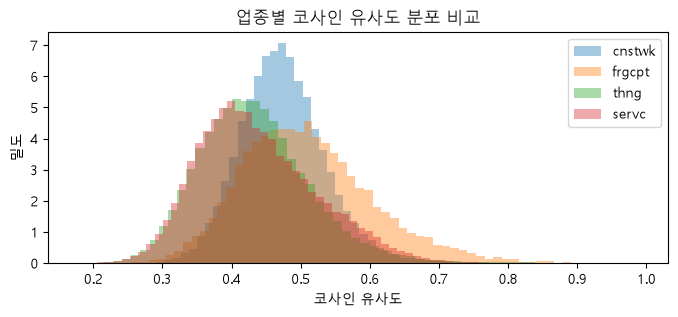

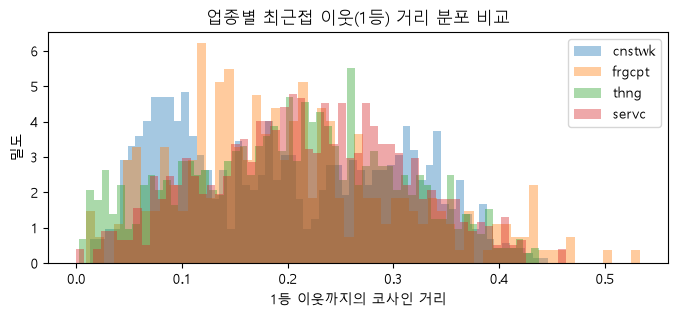

업종               건수      코사인평균     1등거리평균
cnstwk        1,526     0.4748     0.1973
frgcpt          313     0.5094     0.2017
thng          7,009     0.4333     0.2025
servc         7,513     0.4371     0.2195


In [35]:
# 업종 4개를 겹쳐서 그린다 - 어느 업종이 유독 촘촘한지(밀도 높은지) 한눈에 비교
category_sims = {"cnstwk": sims_cnstwk, "frgcpt": sims_frgcpt, "thng": sims_thng, "servc": sims_servc}
category_nn = {"cnstwk": nn_cnstwk, "frgcpt": nn_frgcpt, "thng": nn_thng, "servc": nn_servc}

plt.figure(figsize=(8, 3))
for name, sims_c in category_sims.items():
    plt.hist(sims_c, bins=60, alpha=0.4, density=True, label=name)
plt.xlabel("코사인 유사도")
plt.ylabel("밀도")
plt.title("업종별 코사인 유사도 분포 비교")
plt.legend()
plt.show()

plt.figure(figsize=(8, 3))
for name, nn_c in category_nn.items():
    plt.hist(nn_c[:, 0], bins=60, alpha=0.4, density=True, label=name)
plt.xlabel("1등 이웃까지의 코사인 거리")
plt.ylabel("밀도")
plt.title("업종별 최근접 이웃(1등) 거리 분포 비교")
plt.legend()
plt.show()

# 요약 표
print(f"{'업종':10} {'건수':>8} {'코사인평균':>10} {'1등거리평균':>10}")
for name in category_sims:
    n_cat = mask_cnstwk.sum() if name == "cnstwk" else (
        mask_frgcpt.sum() if name == "frgcpt" else (
        mask_thng.sum() if name == "thng" else mask_servc.sum()))
    print(f"{name:10} {n_cat:>8,} {category_sims[name].mean():>10.4f} {category_nn[name][:, 0].mean():>10.4f}")

**해석 (7단계 업종별 재확인)**

| 업종 | 건수 | 코사인 평균 | p5 ~ p95 | 분포 폭 | 1등 이웃 | 10등 이웃 |
|---|---|---|---|---|---|---|
| cnstwk | 1,526 | 0.4748 | 0.3805~0.5806 | **0.200** | **0.1973** | **0.3432** |
| frgcpt | 313 | **0.5094** | 0.3723~0.6828 | **0.311** | 0.2017 | 0.3315 |
| thng | 7,009 | 0.4333 | 0.3155~0.5756 | 0.260 | 0.2025 | 0.3098 |
| servc | 7,513 | 0.4371 | 0.3153~0.5952 | 0.280 | **0.2195** | 0.3250 |
| (전체) | 17,121 | 0.4125 | 0.3048~0.5480 | 0.243 | 0.2027 | 0.3123 |

- **네 업종 모두 전체 평균(0.4125)보다 코사인 유사도가 높다** — 가장 낮은 thng(0.4333)조차 전체를 웃돈다. 전체 평균이 낮은 건 업종이 다른 쌍(servc vs cnstwk 등)이 섞여 끌어내린 결과이고, **같은 업종끼리는 항상 더 비슷하다.** 4-3에서 시각적으로 본 "업종별 분리"가 수치로도 확인된다.

- **cnstwk: 가장 균질하다** — 코사인 분포 폭이 0.200으로 가장 좁고(p5가 0.3805로 유독 높음), 1등 이웃 거리도 가장 짧다(0.1973). 공사 공고는 제목 형식이 정형화돼 있어("~공사", "~정비공사") 어휘가 서로 비슷하다는 뜻이다. 다만 **10등 이웃 거리는 가장 길다(0.3432)** — 아주 가까운 몇 건을 벗어나면 빠르게 성겨진다. 소수의 판박이 공고 + 나머지는 서로 구별되는 구조로, **뚜렷한 소그룹이 잘 잡힐 가능성이 높다.**

- **frgcpt: 평균은 가장 높은데 분포 폭도 가장 넓다(0.311)** — 평균만 봤을 땐 "제일 균질하다"고 읽힐 뻔했는데, 퍼센타일을 보니 반대다. p95가 0.6828로 유독 튀는데, 이는 **일부는 극단적으로 서로 비슷하고(정형화된 "외자(...)" 표기) 일부는 꽤 다르다**는 뜻이다. 313건이라는 적은 건수와 합쳐서 보면, 소수의 밀집 그룹 + 흩어진 나머지 형태로 예상된다.

- **servc: 1등 이웃 거리가 가장 길다(0.2195, 전체 평균보다도 큼)** — 7,513건으로 두 번째로 많은데도 가장 성기다. 서비스 성격이 그만큼 다양하다는 뜻이고, 앞서 훑어봤을 때 8가지 정도의 뚜렷이 다른 성격(정책연구·IT구축·실태조사·건설감리·유지관리·정보보호·운영위탁·기능개선)이 나왔던 것과 일치한다.

- **thng: 모든 지표가 전체 평균에 가장 가깝다** — 유독 튀는 특징이 없다. 다만 2-3에서 확인한 반복 발주(레미콘 등) 패턴이 있어, 실제 클러스터링에서는 품목군별 하위 그룹이 나올 것으로 예상된다.

**다음 단계 반영 (K 후보 조정)**

6번 결론의 초안을 이 수치로 조정한다.

| 업종 | 6번 초안 | 조정안 | 근거 |
|---|---|---|---|
| servc | 6~10 | **8~12** | 1등 이웃 거리가 가장 김 = 가장 다양함 |
| thng | 6~10 | 6~10 (유지) | 전체 평균과 가장 유사, 조정 근거 없음 |
| cnstwk | 4~6 | **5~8** | 분포가 균질하되 10등 거리가 길어 소그룹이 뚜렷할 것 |
| frgcpt | 3~4 | 3~5 | 분포 폭이 넓어 최소값보다는 여유를 둠 |

## 8. 다음 노트북으로 데이터 전달

전처리 확정본(중복 제거 17,121건)을 파일로 저장한다. 02_clustering.ipynb가 이걸 읽어서 시작한다.

In [36]:
# 중복 제거 확정본 저장 - 벡터는 npy(바이너리, 빠름), 메타는 csv(pandas로 바로 읽기 좋음)
# utf-8-sig: 엑셀에서 열어도 한글이 안 깨지게 하는 BOM 포함 인코딩
np.save(CACHE / "vectors_dedup.npy", Xn_dedup)
df_dedup.to_csv(CACHE / "meta_dedup.csv", index=False, encoding="utf-8-sig")

print(f"저장 완료: {len(df_dedup):,}건")
print(f"  {CACHE / 'vectors_dedup.npy'}")
print(f"  {CACHE / 'meta_dedup.csv'}")

저장 완료: 17,121건
  cache\vectors_dedup.npy
  cache\meta_dedup.csv


-